# Project: Automated ECG Analysis & Clinical Metric Extraction
**Author:** [Debalina Bhaumik] | **Domain:** Biomedical Engineering & Data Science

### 1. Clinical Objective
The goal of this pipeline is to process raw ambulatory ECG signals to extract **Heart Rate (BPM)**. 
Reliable peak detection is the foundation for diagnosing arrhythmias such as **Tachycardia** and **Bradycardia**.

### 2. Dataset Specification
*   **Source:** MIT-BIH Arrhythmia Database (via PhysioNet).
*   **Sampling Frequency ($f_s$):** 360 Hz.
*   **Signal Type:** Lead II ECG.

### 3. Engineering Strategy & Risk Mitigation
*   **Filtering:** A 5th-order **Butterworth Bandpass Filter (0.5 - 40 Hz)** is implemented. 
    *   *Rationale:* The 0.5 Hz high-pass removes **baseline wander** (respiratory artifacts), while the 40 Hz low-pass removes **EMG noise** and powerline interference.
*   **Validation:** Detection is performed using the **xqrs algorithm**, which is robust against high T-wave morphology that often causes "double-counting" in simpler threshold models.

---



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


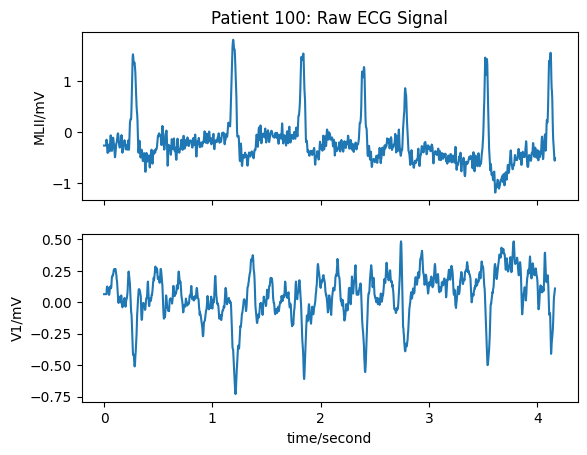

In [8]:

import sys
!{sys.executable} -m pip install wfdb matplotlib

# Step 2: Import the tools
import wfdb
import matplotlib.pyplot as plt

# Step 3: Download and read 5 seconds of an ECG
# '100' is the patient ID from the MIT-BIH Arrhythmia Database
record = wfdb.rdrecord('203' \
'', pn_dir='mitdb', sampto=1500)

# Step 4: Visualize it
wfdb.plot_wfdb(record=record, title='Patient 100: Raw ECG Signal')


Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Total heartbeats detected: 7


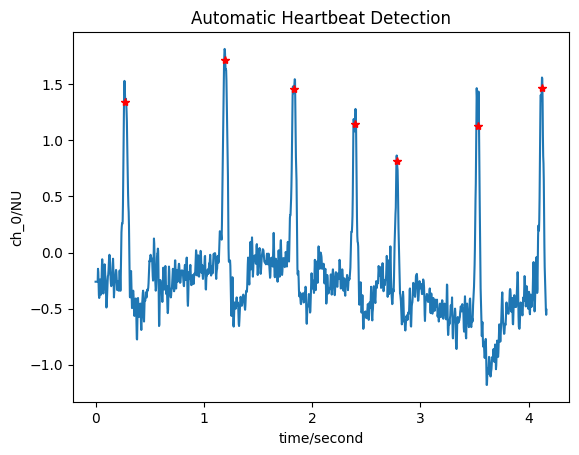

In [9]:
from wfdb import processing

# 1. This algorithm "hunts" for the QRS complex (the main spike of the heartbeat)
# We use the 'record' variable we created in the previous step
peaks = processing.xqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

# 2. Let's see how many beats were found in those 5 seconds
print(f"Total heartbeats detected: {len(peaks)}")

# 3. Plot the signal again, but this time "mark" where the algorithm thinks the beats are
wfdb.plot_items(signal=record.p_signal[:,0], ann_samp=[peaks], 
                title='Automatic Heartbeat Detection',
                time_units='seconds', fs=record.fs)


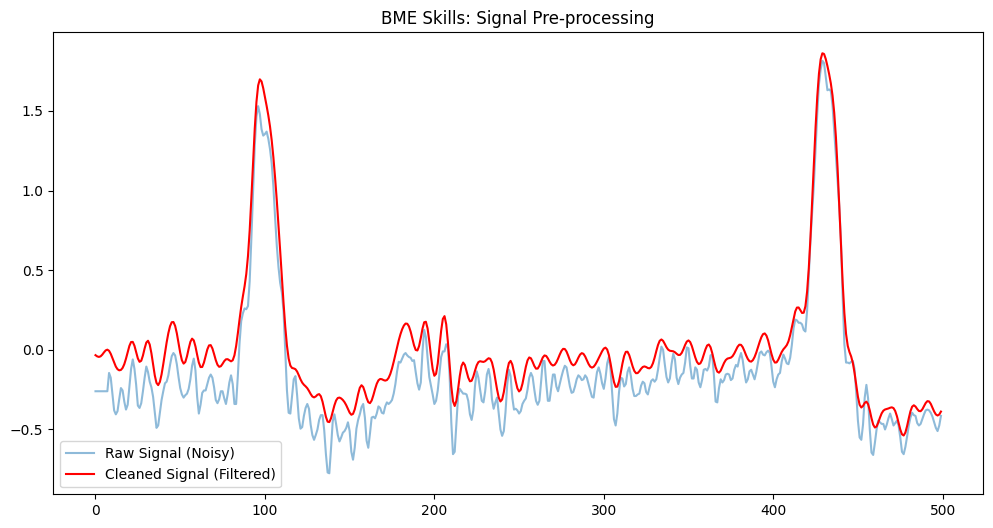

In [10]:
from scipy.signal import butter, filtfilt

# 1. Define the Filter (Standard ECG range is 0.5Hz to 40Hz)
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# 2. Apply the filter to your 'record' signal
fs = record.fs  # The sampling frequency of the MIT-BIH data
cleaned_signal = butter_bandpass_filter(record.p_signal[:,0], 0.5, 40, fs)

# 3. Compare Raw vs. Cleaned
plt.figure(figsize=(12, 6))
plt.plot(record.p_signal[:500,0], label='Raw Signal (Noisy)', alpha=0.5)
plt.plot(cleaned_signal[:500], label='Cleaned Signal (Filtered)', color='red')
plt.legend()
plt.title("BME Skills: Signal Pre-processing")
plt.show()


In [11]:
# 1. Calculate the distance between peaks (in samples)
import numpy as np
rr_intervals = np.diff(peaks)

# 2. Convert samples to seconds (fs is samples per second)
rr_seconds = rr_intervals / fs

# 3. Calculate BPM (60 seconds / average RR interval)
avg_rr = np.mean(rr_seconds)
bpm = 60 / avg_rr

print(f"Calculated Heart Rate: {bpm:.2f} BPM")

# 4. Clinical Logic
if bpm > 100:
    print("Status: Tachycardia Detected (Clinical Alert)")
elif bpm < 60:
    print("Status: Bradycardia Detected (Clinical Alert)")
else:
    print("Status: Normal Sinus Rhythm")


Calculated Heart Rate: 93.64 BPM
Status: Normal Sinus Rhythm
